In [2]:
# Import Data Manipulation and Visualization Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore') # Keeps your notebook looking clean

print("All libraries imported successfully!")


All libraries imported successfully!


In [3]:
# Load the dataset
# IMPORTANT: Replace 'heart.csv' with the actual name of your data file if it's different!
heart_df = pd.read_csv('heart.csv') 

# Display the first 5 rows to confirm it loaded correctly
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


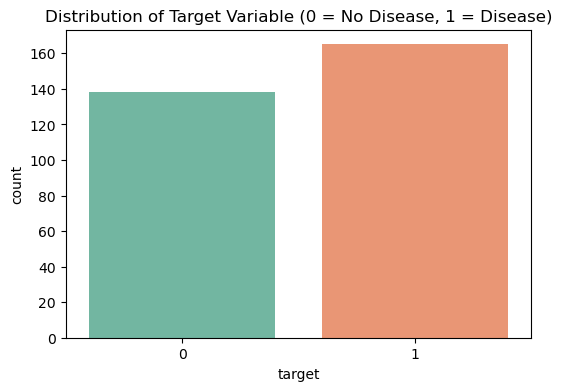

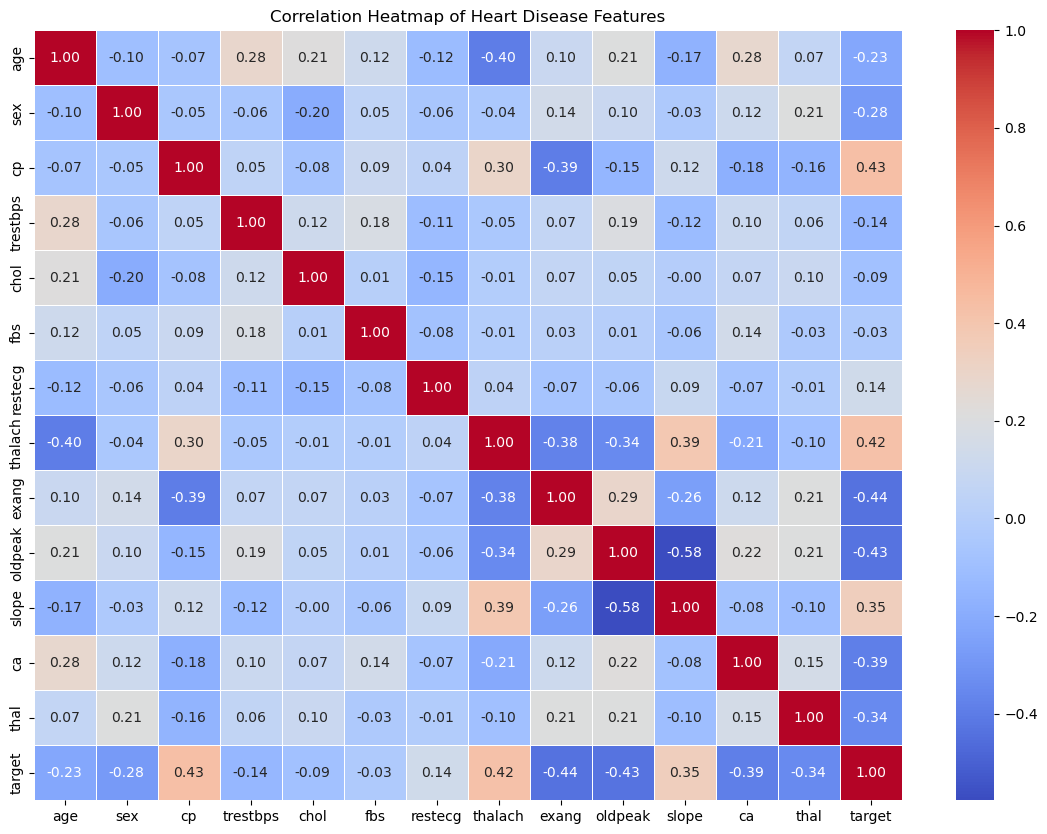

In [4]:
## Exploratory Data Analysis (EDA)

# 1. Visualize the Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=heart_df, palette='Set2')
plt.title('Distribution of Target Variable (0 = No Disease, 1 = Disease)')
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(heart_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Heart Disease Features')
plt.show()

In [5]:
## Data Preprocessing

# Separate Features (X) and Target (y)
X = heart_df.drop('target', axis=1)
y = heart_df['target']

# Split into Training (80%) and Testing (20%) data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data ready: {X_train_scaled.shape}")
print(f"Testing data ready: {X_test_scaled.shape}")

Training data ready: (242, 13)
Testing data ready: (61, 13)


In [6]:
## Model Training

# Initialize and train the Logistic Regression model
log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

print("Logistic Regression Model trained successfully!")

Logistic Regression Model trained successfully!


Accuracy:  85.25%
Precision: 87.10%
Recall:    84.38%
F1-Score:  85.71%


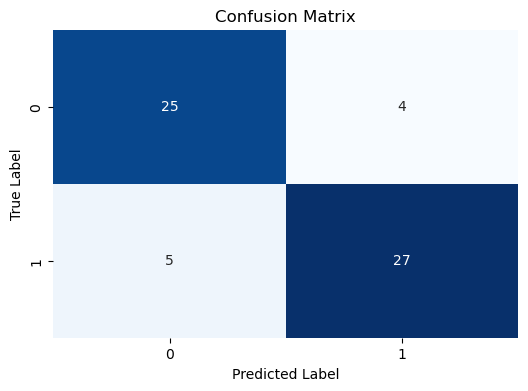

In [7]:
## Model Evaluation

# Make predictions
y_pred = log_model.predict(X_test_scaled)

# Calculate metrics
print(f"Accuracy:  {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred) * 100:.2f}%")
print(f"Recall:    {recall_score(y_test, y_pred) * 100:.2f}%")
print(f"F1-Score:  {f1_score(y_test, y_pred) * 100:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()